In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import *
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from numpy import argmax
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from yellowbrick.classifier import ROCAUC, ClassificationReport, PrecisionRecallCurve
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

In [3]:
training_set = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [4]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
training_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
training_set.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [7]:
def custom_hist(training_set, title,  xlabel, ylabel='Количество', bins=None):
    figsize = (20,6)
    plt.figure(figsize=figsize)
    plt.grid(True)
    plt.title(title)
    plt.hist(training_set, training_set.max().astype(int) if bins is None else bins)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

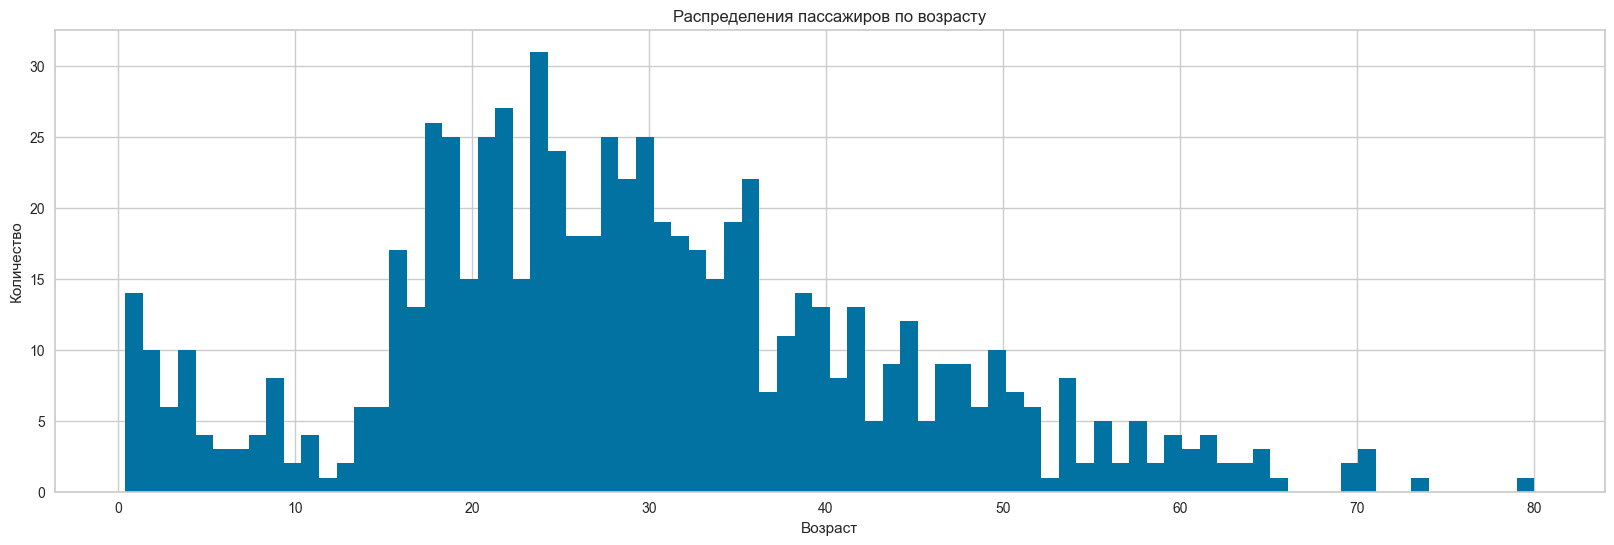

In [8]:
custom_hist(training_set["Age"], 'Распределения пассажиров по возрасту', 'Возраст')

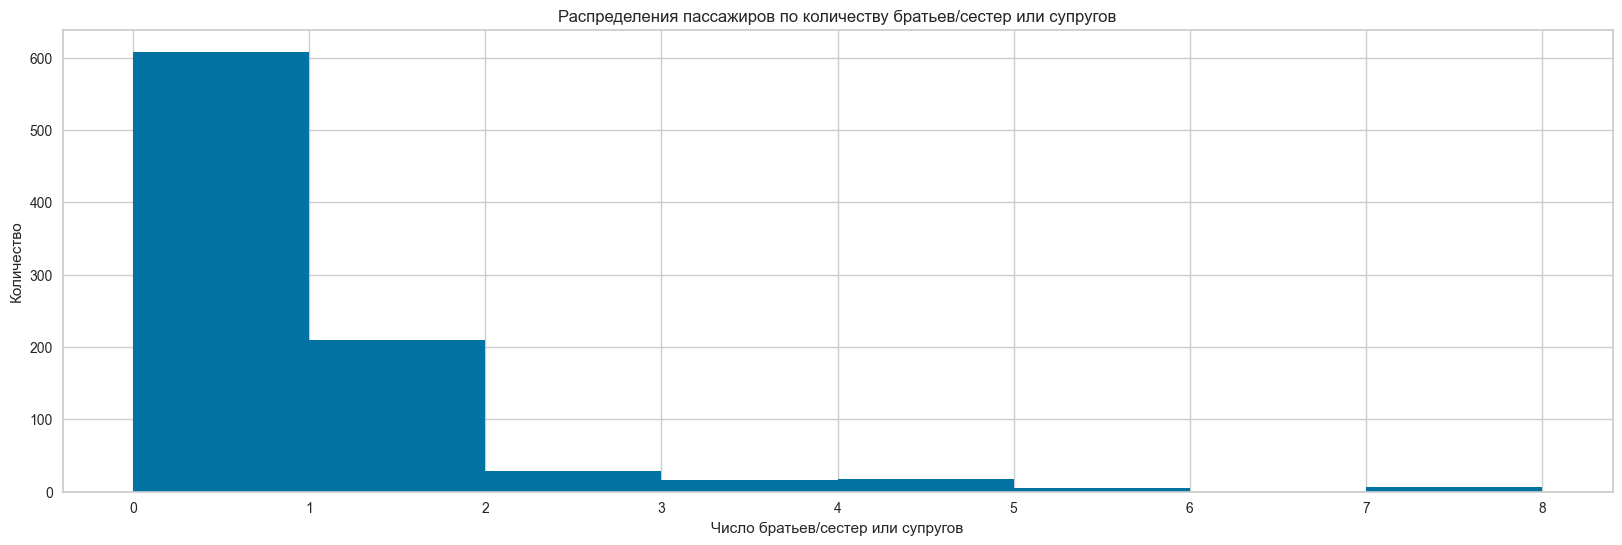

In [9]:
custom_hist(training_set["SibSp"], 'Распределения пассажиров по количеству братьев/сестер или супругов', 
  'Число братьев/сестер или супругов')

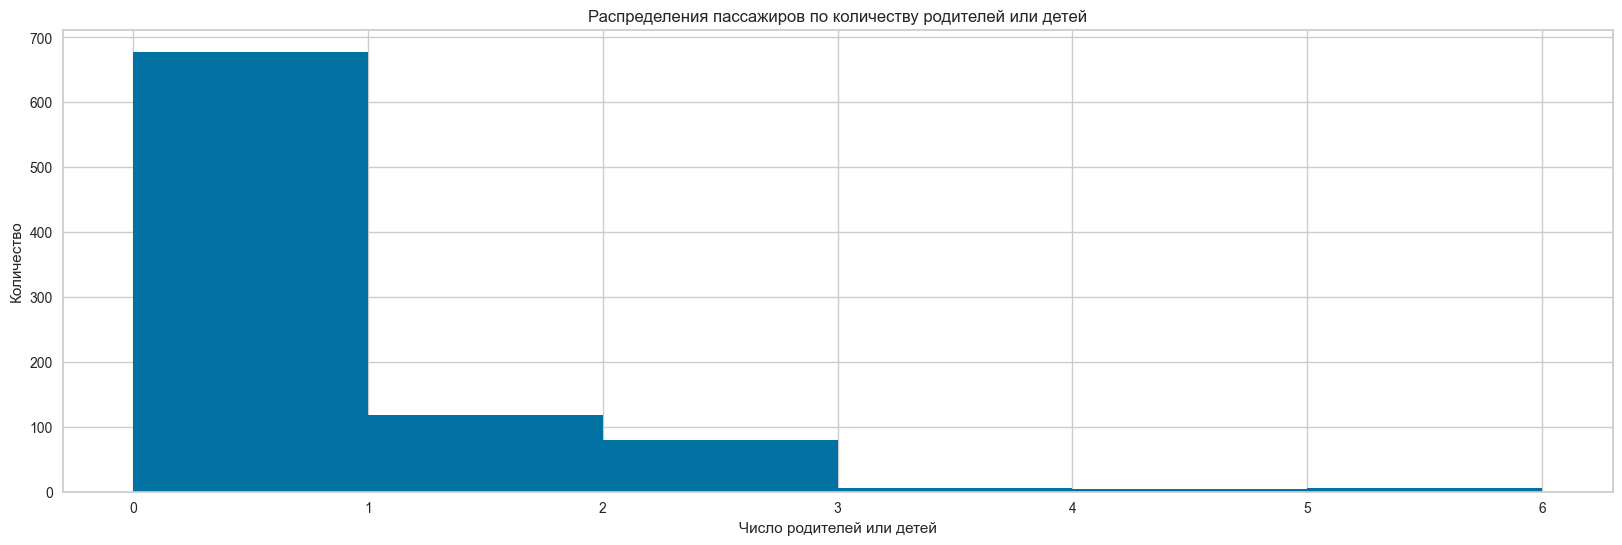

In [10]:
custom_hist(training_set["Parch"], 'Распределения пассажиров по количеству родителей или детей', 
  'Число родителей или детей')

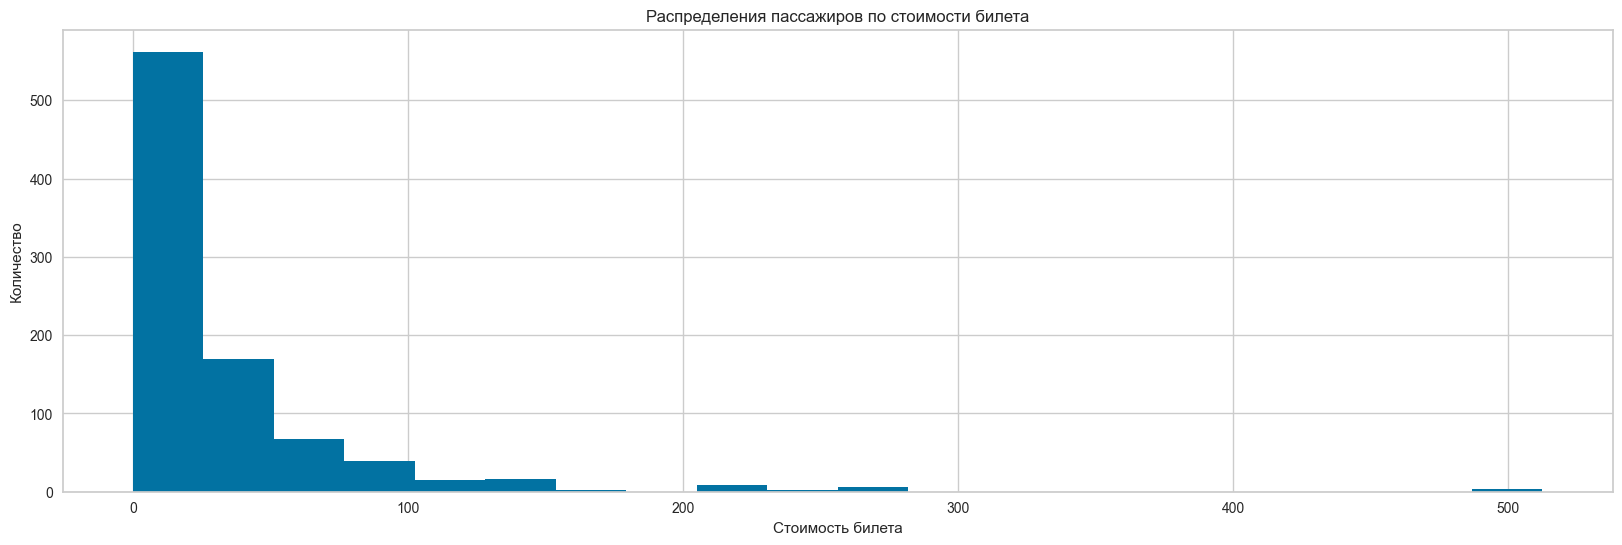

In [11]:
custom_hist(training_set["Fare"], 'Распределения пассажиров по стоимости билета', 
  'Стоимость билета', bins=20)

<Axes: ylabel='Frequency'>

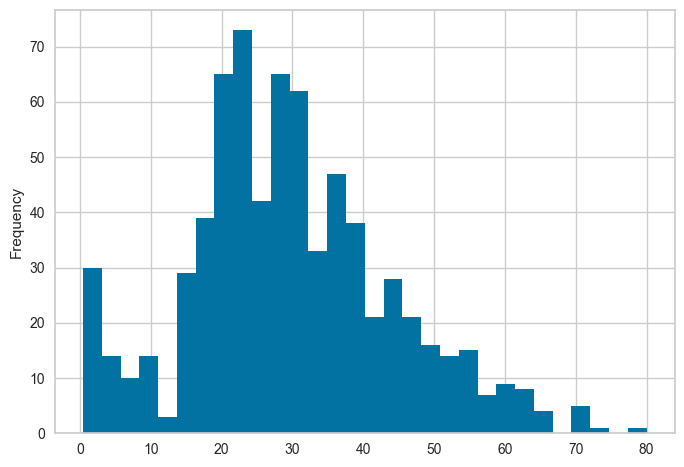

In [12]:
training_set['Age'].plot.hist(bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

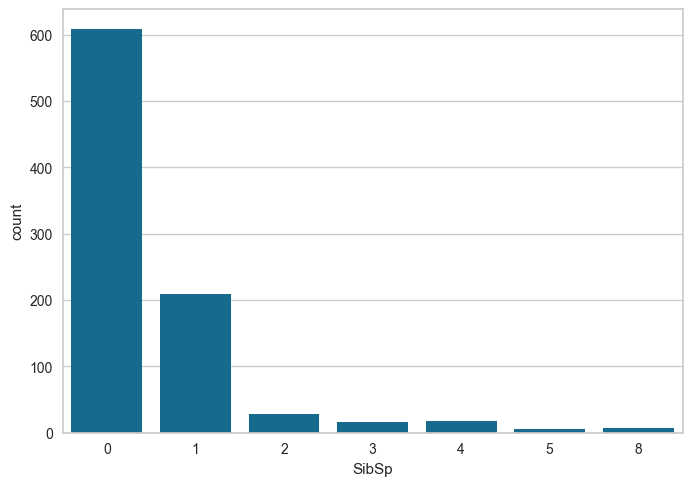

In [13]:
sns.countplot(x='SibSp', data=training_set)

<Axes: xlabel='SibSp', ylabel='count'>

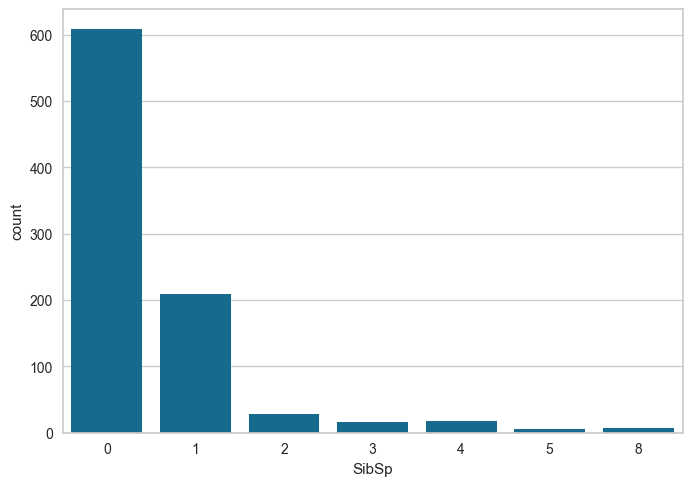

In [14]:
sns.countplot(x='SibSp', data=training_set)

In [15]:
training_set['Fare']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

<Axes: >

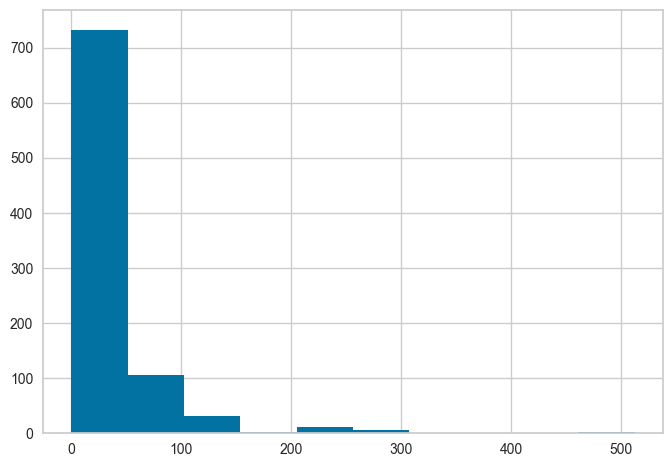

In [16]:
training_set['Fare'].hist()

<Axes: >

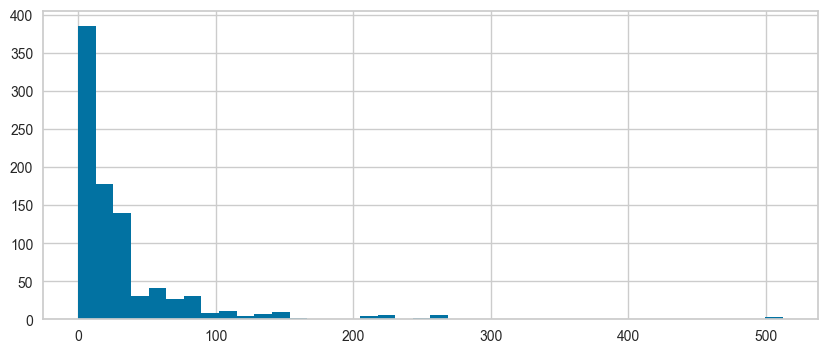

In [17]:
training_set['Fare'].hist(bins=40, figsize=(10,4))

<Axes: xlabel='Survived', ylabel='count'>

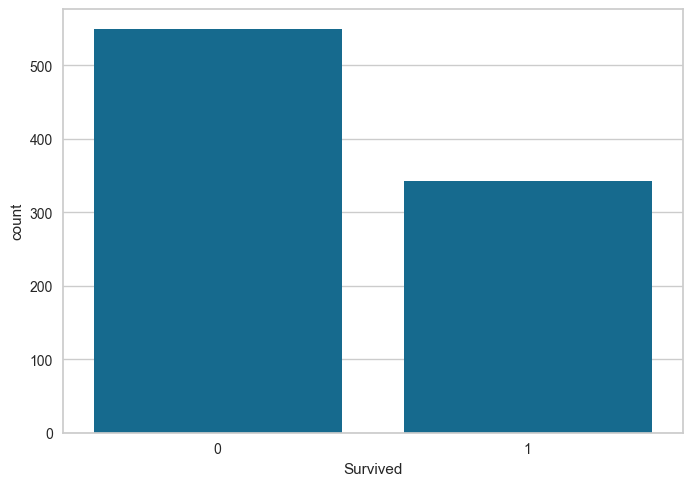

In [18]:
sns.countplot(x='Survived', data=training_set)

<Axes: xlabel='Survived', ylabel='count'>

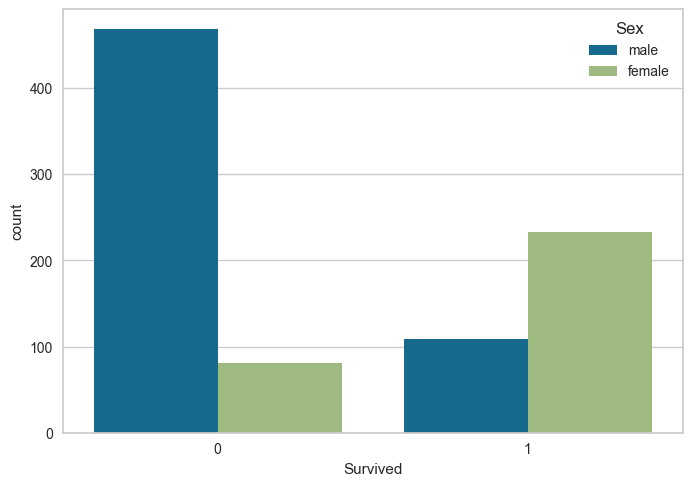

In [19]:
sns.countplot(x='Survived', data=training_set, hue='Sex')

<Axes: xlabel='Survived', ylabel='count'>

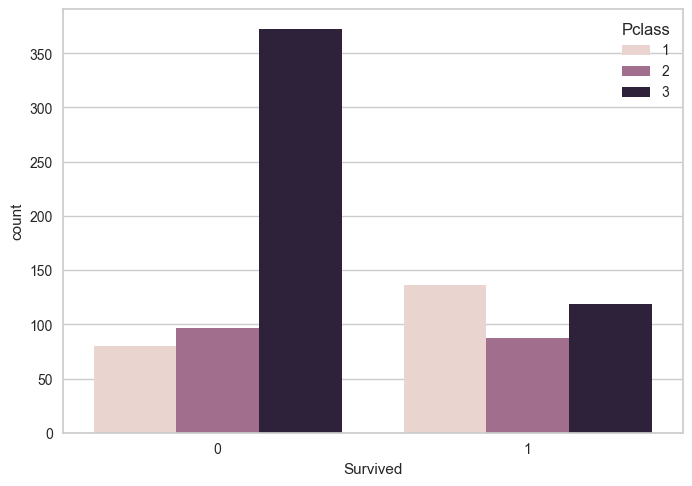

In [20]:
sns.countplot(x='Survived', data=training_set, hue='Pclass')

<Axes: xlabel='Pclass', ylabel='Age'>

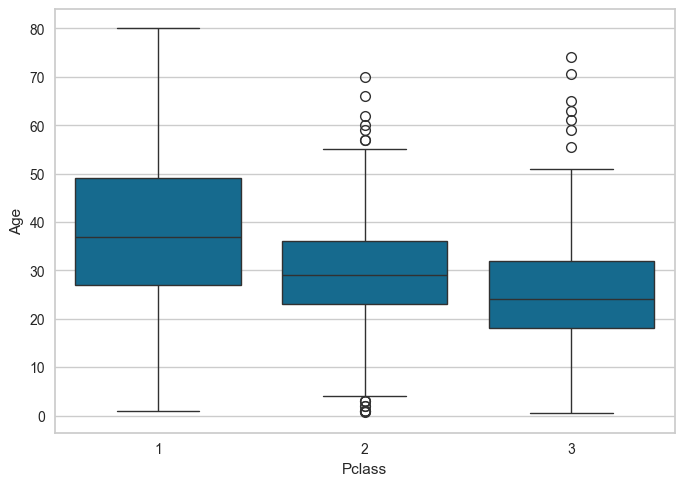

In [21]:
sns.boxplot(x='Pclass', y='Age', data=training_set)

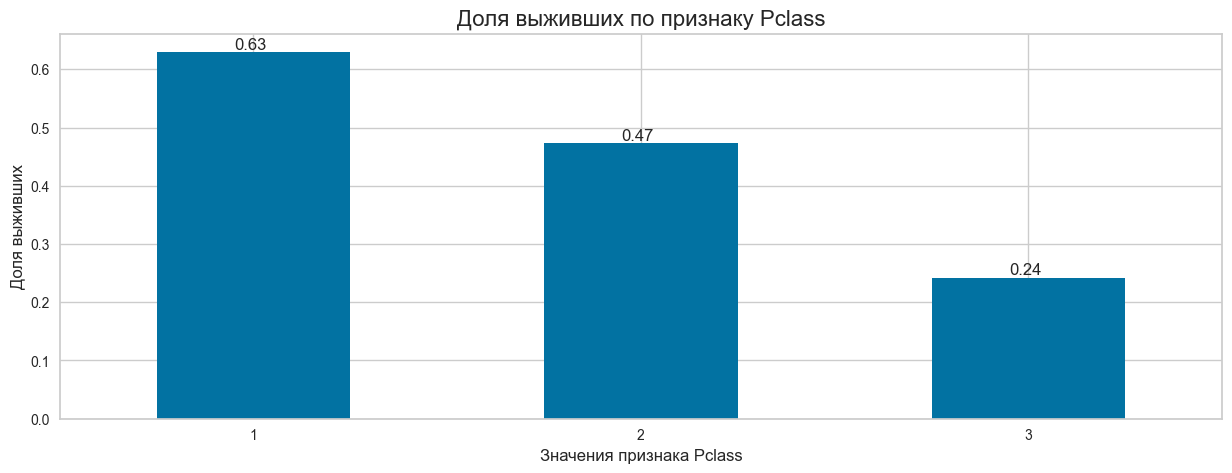

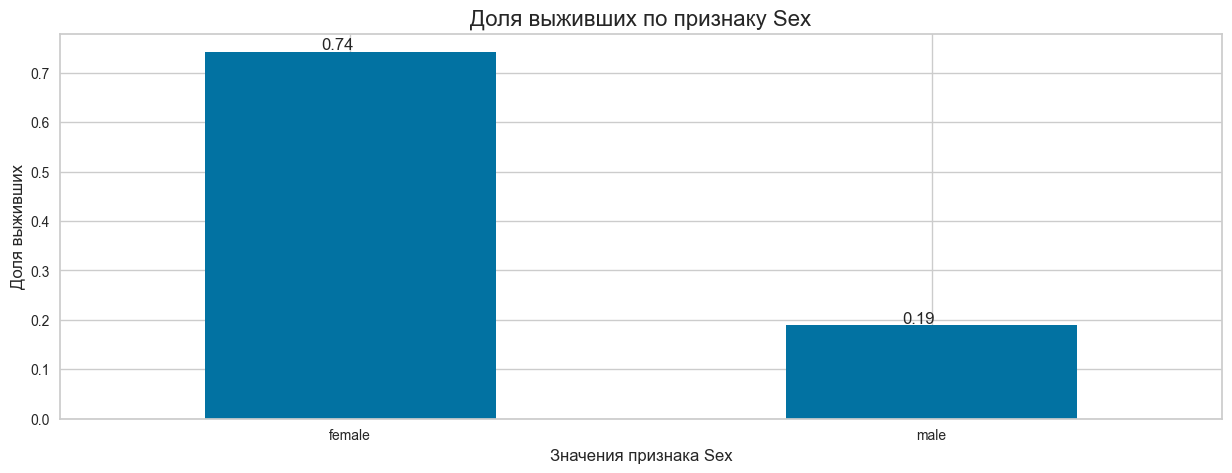

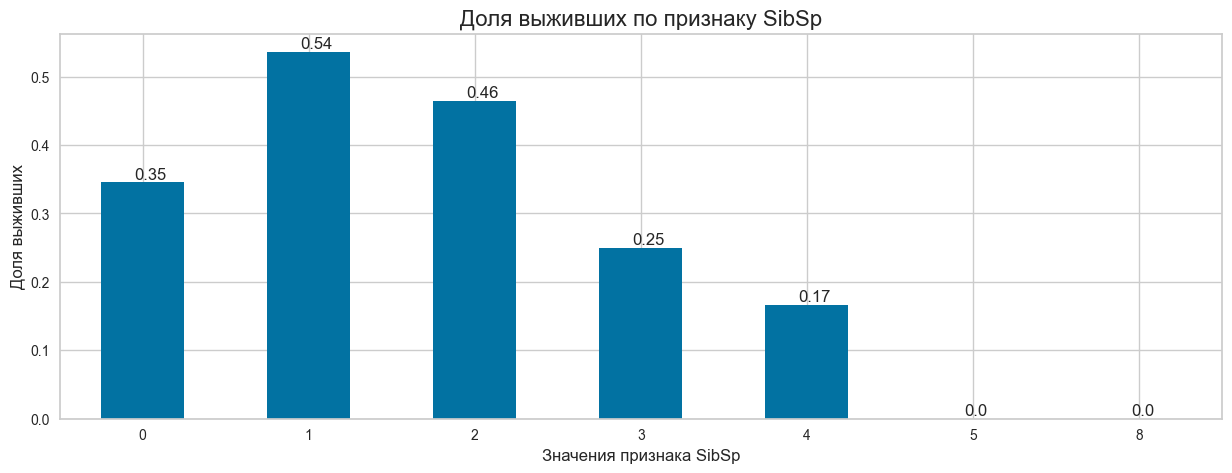

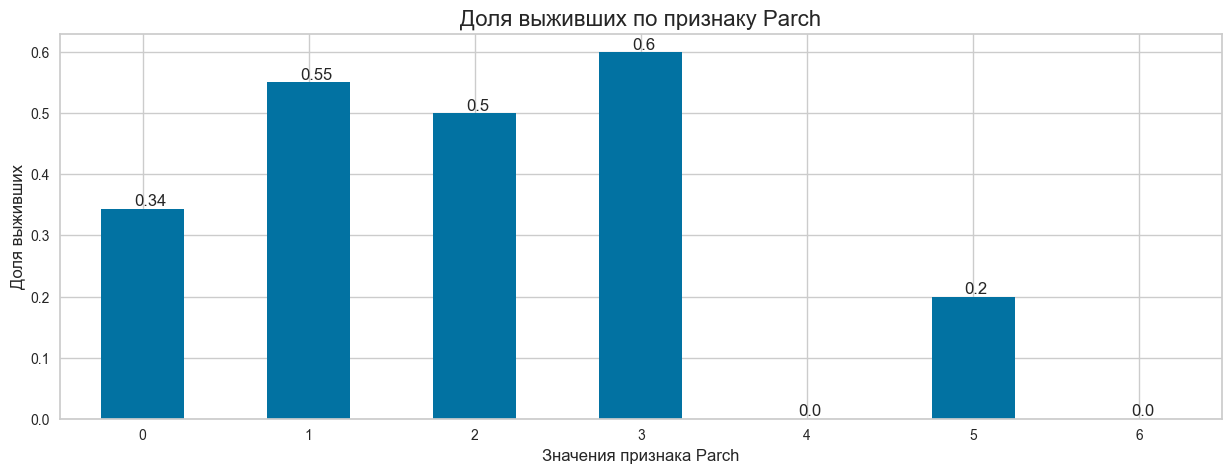

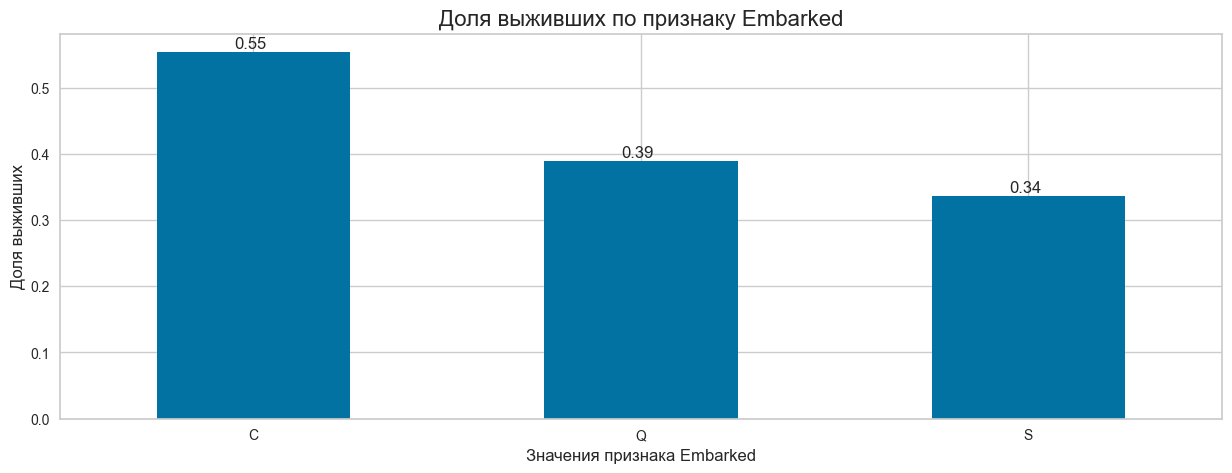

In [22]:
columns_to_look = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

for column in columns_to_look:
    pivot = training_set.pivot_table(index=column, values='Survived', aggfunc='mean')
    
    fig, ax = plt.subplots(figsize=(15,5))
    ax.set_title(f'Доля выживших по признаку {column}', fontdict={'size': 16})
    ax.set_ylabel('Доля выживших', fontdict={'size': 12})
    ax.set_xlabel(column, fontdict={'size': 12})
    
    for cnt in range(pivot.shape[0]):
        value = pivot.iloc[cnt].values[0]
        ax.text(cnt - .05, value + .005, round(value, 2))
        
    pivot.plot(kind='bar', rot=0, grid=True, legend=False, ax=ax) 
    ax.set_xlabel(f'Значения признака {column}', fontdict={'size': 12})
    plt.show()

In [23]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [24]:
training_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [25]:
training_set.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [26]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: >

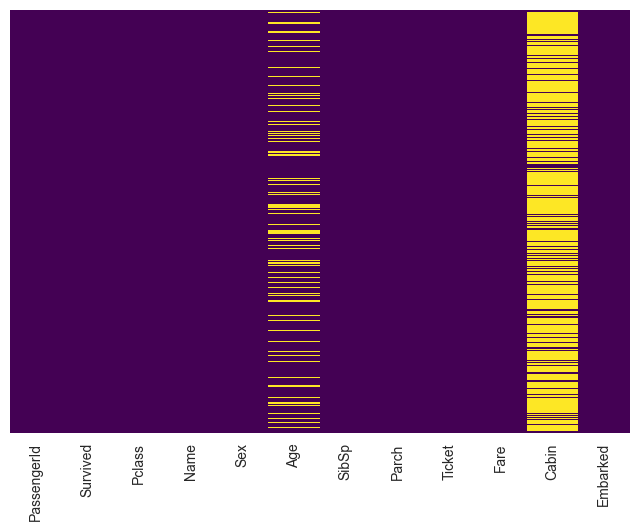

In [28]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [30]:
training_set.drop('Cabin', axis=1, inplace=True)

In [31]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: >

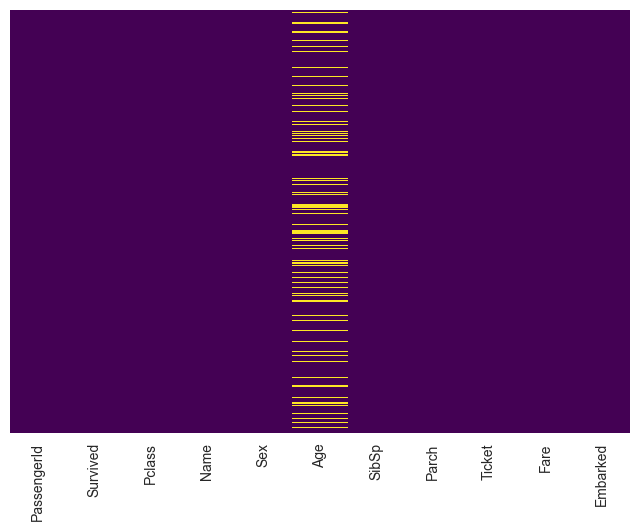

In [32]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [33]:
training_set.dropna(inplace=True)

<Axes: >

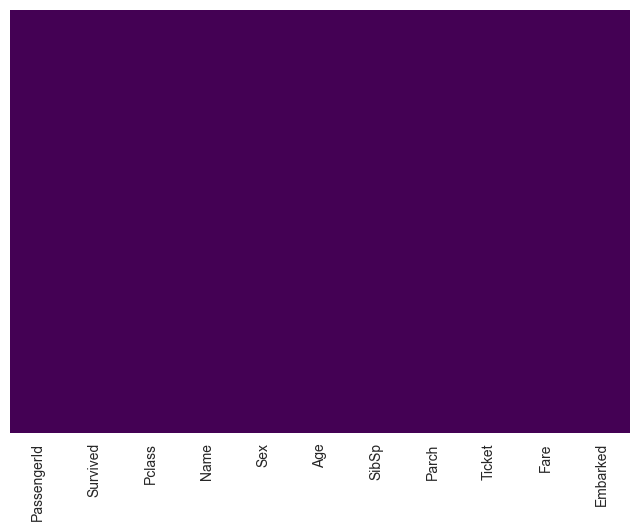

In [34]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [35]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [37]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(training_set['Sex'])

In [38]:
training_set['Sex'].unique()

array(['male', 'female'], dtype=object)

In [39]:
np.unique(cat_enc_le)  

array([0, 1])

In [40]:
le.inverse_transform([0,1])

array(['female', 'male'], dtype=object)

In [41]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(training_set[['Embarked']])  # Вызываем метод fit_transform, возвращает разреженную матрицу из библиотеки Scipy 

In [42]:
training_set.shape

(712, 11)

In [43]:
cat_enc_ohe.shape

(712, 3)

In [44]:
pd.get_dummies(training_set['Sex'])

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
885,True,False
886,False,True
887,True,False
889,False,True


In [45]:
pd.get_dummies(training_set['Sex'], drop_first=True)

,male
0,True
1,False
2,False
3,False
4,True
...,...
885,False
886,True
887,False
889,True


In [46]:
sex = pd.get_dummies(training_set['Sex'], drop_first=True)

In [47]:
embark = pd.get_dummies(training_set['Embarked'], drop_first=True)

In [48]:
embark.head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [49]:
training_set = pd.concat([training_set, sex, embark], axis=1)

In [50]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,False,True


In [51]:
training_set.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [52]:
training_set.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## Практические задания

### 1) Постройте по получившемуся набору данных простую модель машинного обучения и оцените ее эффективность.

In [53]:
X = training_set.drop('Survived', axis=1)
y = training_set['Survived']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [56]:
y_pred = model.predict(X_test)

In [58]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.3f}")
print(classification_report(y_test, y_pred))

Точность модели: 0.797
              precision    recall  f1-score   support

           0       0.77      0.91      0.83        80
           1       0.85      0.65      0.74        63

    accuracy                           0.80       143
   macro avg       0.81      0.78      0.79       143
weighted avg       0.81      0.80      0.79       143



Модель логистической регрессии достигла точности 79.7% на тестовой выборке. Модель лучше предсказывает выживших (класс 0) с полнотой 91%, чем погибших (класс 1) с полнотой 65%, что может быть связано с дисбалансом классов или недостаточностью признаков. В целом, модель демонстрирует приемлемое качество для базового решения.

## 2) Ответьте на следующие вопросы при помощи визуализации и численных данных по исходному набору данных:

## 3) Какова доля выживших после крушения пассажиров? Какова доля мужчин и женщин среди выживших?

In [59]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [60]:
survived_rate = df['Survived'].mean()
print(f"Доля выживших пассажиров: {survived_rate:.3f} ({survived_rate*100:.1f}%)")
print(f"Выжило: {df['Survived'].sum()} из {len(df)} пассажиров")

Доля выживших пассажиров: 0.384 (38.4%)
Выжило: 342 из 891 пассажиров


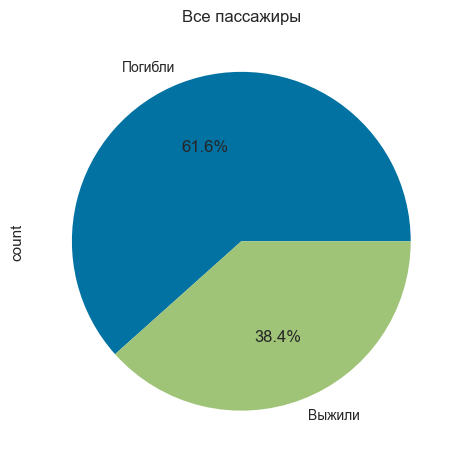

In [64]:
df['Survived'].value_counts().plot(kind='pie', labels=['Погибли', 'Выжили'], autopct='%1.1f%%')
plt.title('Все пассажиры')

survived = df[df['Survived'] == 1]
survived_sex = survived['Sex'].value_counts()

(array([0, 1]), [Text(0, 0, 'female'), Text(1, 0, 'male')])

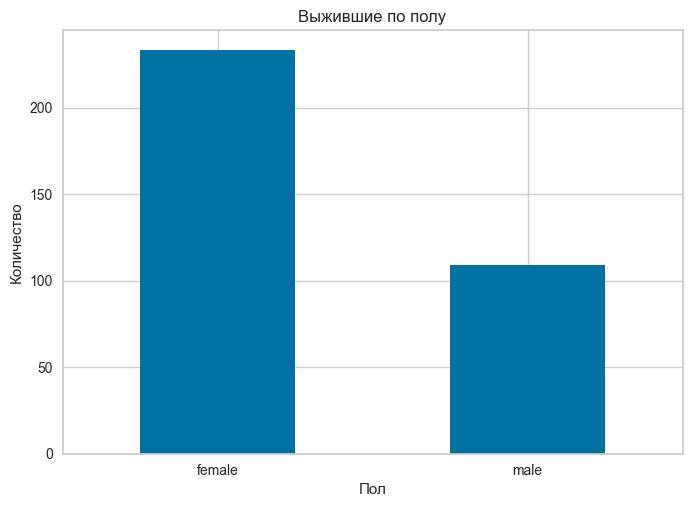

In [65]:
survived_sex.plot(kind='bar')
plt.title('Выжившие по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.xticks(rotation=0)

### 4) Сколько пассажиров ехало в каждом классе? Кого было больше в самом многолюдном классе — мужчин или женщин?

In [70]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [71]:
print(df['Pclass'].value_counts().sort_index())
print(f"\nВ 3-м классе больше: {df[df['Pclass']==3]['Sex'].value_counts()}")

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

В 3-м классе больше: Sex
male      347
female    144
Name: count, dtype: int64


### 5) Все ли признаки несут в себе полезную информацию? Почему? Избавьтесь от ненужных столбцов.

In [72]:
print("Пропуски в данных:")
print(df.isnull().sum())
print("\nТипы данных:")
print(df.dtypes)

Пропуски в данных:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


PassengerId - просто индекс, не несет информации  
Name - уникален для каждого, не влияет на выживание  
Ticket - слишком много уникальных значений  
Cabin - 77% пропусков (687 из 891)

In [73]:
df_clean = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

### 6) Посчитайте, насколько сильно коррелируют друг с другом цена за билет и возраст пассажиров. Также проверьте наличие этой зависимости визуально (в этом вам поможет построение диаграммы рассеяния).

In [74]:
corr = df['Fare'].corr(df['Age'])
print(f"Корреляция между ценой билета и возрастом: {corr:.3f}")

Корреляция между ценой билета и возрастом: 0.096


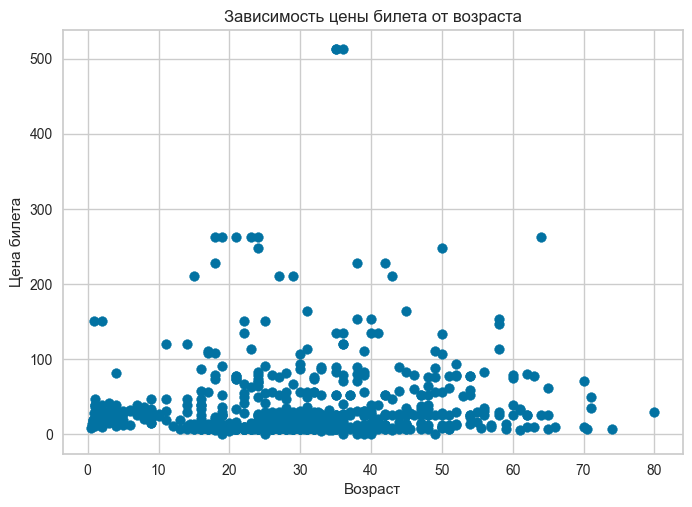

In [76]:
plt.scatter(df['Age'], df['Fare'])
plt.xlabel('Возраст')
plt.ylabel('Цена билета')
plt.title('Зависимость цены билета от возраста')
plt.show()

### 7) Правда ли, что чаще выживали пассажиры с более дорогими билетами? А есть ли зависимость выживаемости от класса?

In [78]:
#средняя цена билетов выживших и погибших
print(f"Выжившие: ${df[df['Survived']==1]['Fare'].mean():.2f}")
print(f"Погибшие: ${df[df['Survived']==0]['Fare'].mean():.2f}")

Выжившие: $48.40
Погибшие: $22.12


In [81]:
#зависимость от класса
for pclass in [1, 2, 3]:
    survived_rate = df[df['Pclass']==pclass]['Survived'].mean()
    print(f"{pclass} класс: {survived_rate:.1%}")

1 класс: 63.0%
2 класс: 47.3%
3 класс: 24.2%


Text(0.5, 0, 'Выжившие (1) / Погибшие (0)')

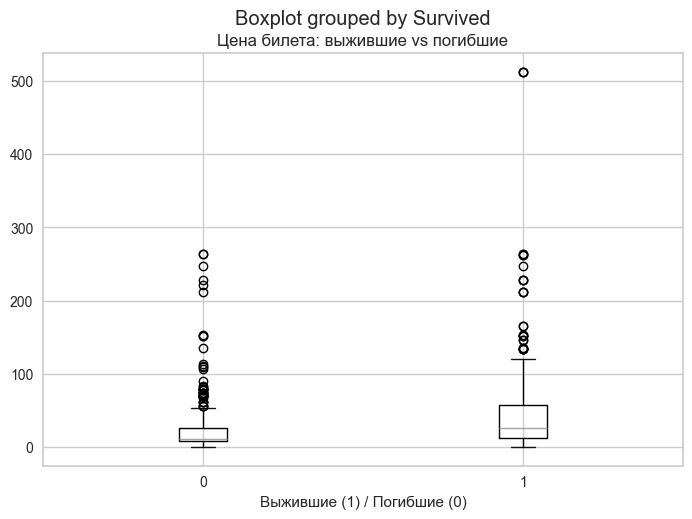

In [84]:
df.boxplot(column='Fare', by='Survived')
plt.title('Цена билета: выжившие vs погибшие')
plt.xlabel('Выжившие (1) / Погибшие (0)')

(array([0, 1, 2]), [Text(0, 0, '1'), Text(1, 0, '2'), Text(2, 0, '3')])

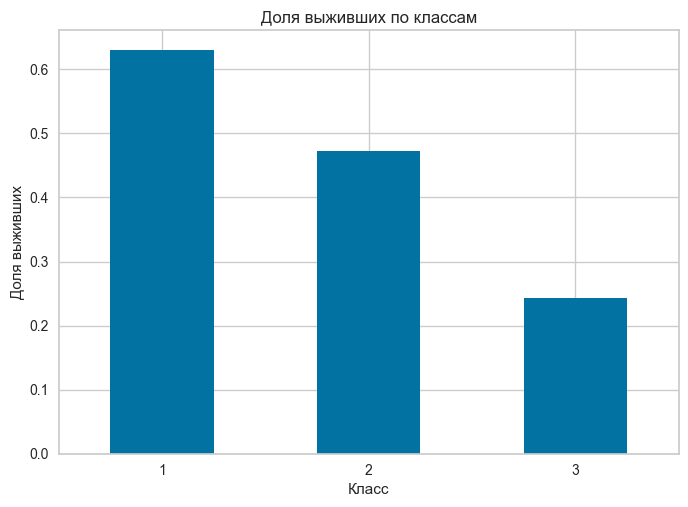

In [86]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title('Доля выживших по классам')
plt.xlabel('Класс')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)

### 8) Какова связь между стоимостью билета и портом отправления? Выведите минимальную, среднюю и максимальную сумму, которую заплатили пассажиры за проезд. Проделайте то же самое только для тех пассажиров, которые сели на корабль в Саутгемптоне.

In [88]:
print("стоимость билета по портам отправления:")
print(df.groupby('Embarked')['Fare'].agg(['min', 'mean', 'max']))

стоимость билета по портам отправления:
             min       mean       max
Embarked                             
C         4.0125  59.954144  512.3292
Q         6.7500  13.276030   90.0000
S         0.0000  27.079812  263.0000


In [91]:
southampton = df[df['Embarked'] == 'S']
print("Пассажиры из Саутгемптона (S):")
print(f"min: ${southampton['Fare'].min():.2f}")
print(f"mean: ${southampton['Fare'].mean():.2f}")
print(f"max: ${southampton['Fare'].max():.2f}")

Пассажиры из Саутгемптона (S):
min: $0.00
mean: $27.08
max: $263.00


### 9) Выведите гистограммы, показывающие распределения стоимостей билетов в зависимости от места посадки.

In [93]:
ports = {'C': 'Шербур', 'Q': 'Квинстаун', 'S': 'Саутгемптон'}

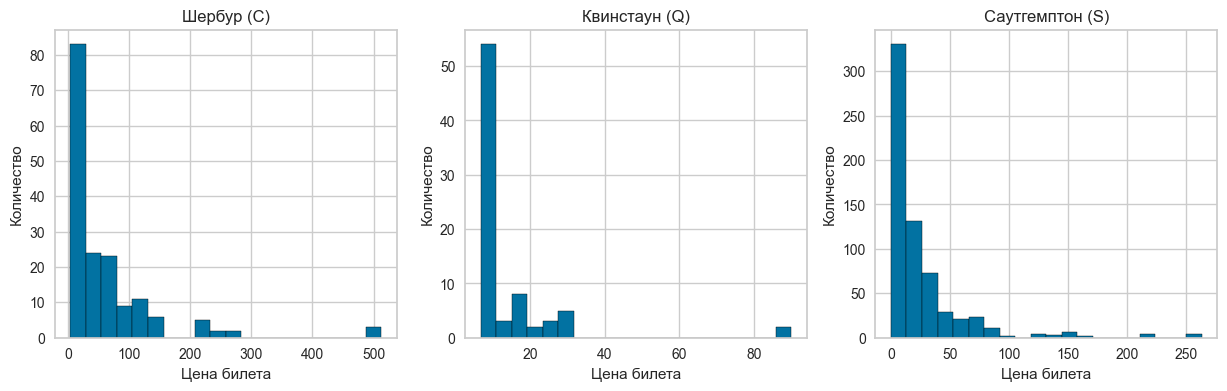

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (port, name) in enumerate(ports.items()):
    data = df[df['Embarked'] == port]['Fare']
    axes[i].hist(data, bins=20, edgecolor='black')
    axes[i].set_title(f'{name} ({port})')
    axes[i].set_xlabel('Цена билета')
    axes[i].set_ylabel('Количество')

### 10) Оцените репрезентативность представленной выборки. Сколько всего было пассажиров Титаника? Сколько из них выжило? Какую долю составляет представленный набор данных от всей генеральной совокупности?

In [102]:
print(f"Всего пассажиров в датасете: {len(df)}")
print(f"Выжило: {df['Survived'].sum()}")
print(f"Погибло: {len(df) - df['Survived'].sum()}")
print(f"Доля выживших: {df['Survived'].mean():.1%}")

Всего пассажиров в датасете: 891
Выжило: 342
Погибло: 549
Доля выживших: 38.4%


Датасет содержит 891 запись пассажиров Титаника.  
Выборка достаточно большая и сбалансированная для анализа.  
Однако отсутствует 60% пассажиров (всего на Титанике было 2224)

### 11) Разделите выборку на тестовую и обучающую части при помощи train_test_split(). Изобразите на графиках распределение некоторых атрибутов и целевой переменной. Насколько однородно получившееся разбиение?

In [105]:
X = df[['Pclass', 'Fare']]
y = df['Survived']

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Text(0.5, 1.0, 'Fare')

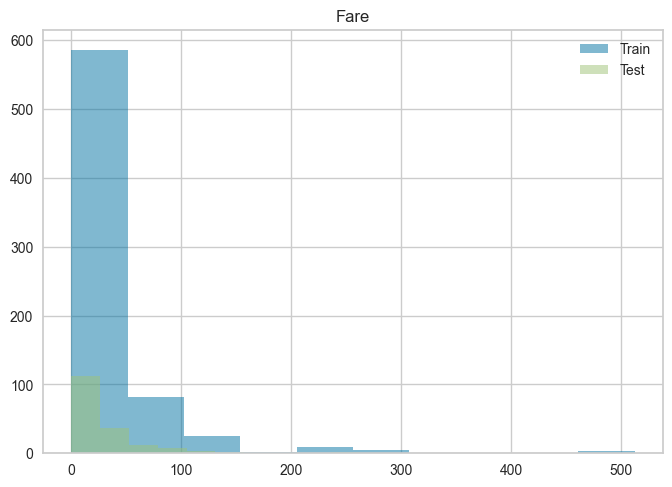

In [108]:
plt.hist(X_train['Fare'], alpha=0.5, label='Train')
plt.hist(X_test['Fare'], alpha=0.5, label='Test')
plt.legend()
plt.title('Fare')

<BarContainer object of 4 artists>

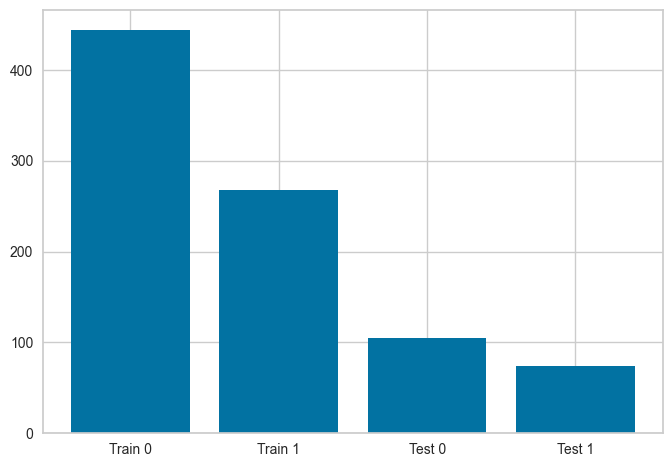

In [110]:
plt.bar(['Train 0', 'Train 1', 'Test 0', 'Test 1'], 
        [sum(y_train==0), sum(y_train==1), sum(y_test==0), sum(y_test==1)])

In [111]:
print(f"Доля выживших: Train={y_train.mean():.2f}, Test={y_test.mean():.2f}")

Доля выживших: Train=0.38, Test=0.41


### 12) Сбалансируйте классы в исходном датасете двумя способами:

### 13) Удалите лишние объекты мажоритарного класса (выбранные случайно)

In [112]:
majority = df[df['Survived'] == 0]
minority = df[df['Survived'] == 1]

In [113]:
majority_downsampled = majority.sample(frac=0.7, random_state=42)

In [115]:
df_balanced = pd.concat([majority_downsampled, minority])

In [116]:
print(f"Было: {len(df)} записей")
print(f"Погибшие (0): {len(majority)}")
print(f"Выжившие (1): {len(minority)}")
print(f"\nСтало: {len(df_balanced)} записей")
print(f"Погибшие (0): {len(majority_downsampled)}")
print(f"Выжившие (1): {len(minority)}")
print(f"Соотношение: {len(majority_downsampled)/len(minority):.1f}:1")

Было: 891 записей
Погибшие (0): 549
Выжившие (1): 342

Стало: 726 записей
Погибшие (0): 384
Выжившие (1): 342
Соотношение: 1.1:1


### 14) Добавьте в выборку дубликаты миноритарного класса.

In [117]:
majority = df[df['Survived'] == 0]
minority = df[df['Survived'] == 1]

In [119]:
minority_upsampled = pd.concat([minority] * 2, ignore_index=True)

In [120]:
df_balanced = pd.concat([majority, minority_upsampled])

In [121]:
print(f"Было: {len(df)} записей")
print(f"Погибшие (0): {len(majority)}")
print(f"Выжившие (1): {len(minority)}")
print(f"\nСтало: {len(df_balanced)} записей")
print(f"Погибшие (0): {len(majority)}")
print(f"Выжившие (1): {len(minority_upsampled)}")
print(f"Соотношение: 1:{len(minority_upsampled)/len(majority):.1f}")

Было: 891 записей
Погибшие (0): 549
Выжившие (1): 342

Стало: 1233 записей
Погибшие (0): 549
Выжившие (1): 684
Соотношение: 1:1.2


### 15) Проведите исследование эффективности простой модели классификации до и после данных преобразований.

In [122]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [123]:
df_processed = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']].copy()
df_processed['Sex'] = (df_processed['Sex'] == 'male').astype(int)
df_processed['Age'] = df_processed['Age'].fillna(df_processed['Age'].median())

In [124]:
X = df_processed.drop('Survived', axis=1)
y = df_processed['Survived']

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [126]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [127]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Recall (выжившие): {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")

Accuracy: 0.793
Recall (выжившие): 0.716
F1-score: 0.741


In [129]:
majority = df_processed[df_processed['Survived'] == 0]
minority = df_processed[df_processed['Survived'] == 1]
majority_down = majority.sample(frac=0.7, random_state=42)
df_down = pd.concat([majority_down, minority])

In [130]:
X_down = df_down.drop('Survived', axis=1)
y_down = df_down['Survived']

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X_down, y_down, test_size=0.2, random_state=42)

In [132]:
scaler = StandardScaler()
model.fit(scaler.fit_transform(X_train), y_train)
y_pred = model.predict(scaler.transform(X_test))

In [133]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")

Accuracy: 0.760
Recall: 0.778
F1-score: 0.737


In [134]:
minority_up = pd.concat([minority] * 2, ignore_index=True)
df_up = pd.concat([majority, minority_up])

In [135]:
X_up = df_up.drop('Survived', axis=1)
y_up = df_up['Survived']
X_train, X_test, y_train, y_test = train_test_split(X_up, y_up, test_size=0.2, random_state=42)

In [136]:
scaler = StandardScaler()
model.fit(scaler.fit_transform(X_train), y_train)
y_pred = model.predict(scaler.transform(X_test))

In [137]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")

Accuracy: 0.814
Recall: 0.803
F1-score: 0.816


Улучшились все метрики модели

### 16) Постройте корреляционную матрицу признаков после преобразования данных. Сделайте вывод о наличии либо отсутствии мультиколлинеарности признаков.

In [138]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [139]:
df_processed = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
df_processed['Sex'] = (df_processed['Sex'] == 'male').astype(int)
df_processed['Age'] = df_processed['Age'].fillna(df_processed['Age'].median())

In [140]:
corr_matrix = df_processed.corr()

In [141]:
print("Корреляционная матрица:")
print(corr_matrix.round(3))

Корреляционная матрица:
          Survived  Pclass    Sex    Age  SibSp  Parch   Fare
Survived     1.000  -0.338 -0.543 -0.065 -0.035  0.082  0.257
Pclass      -0.338   1.000  0.132 -0.340  0.083  0.018 -0.549
Sex         -0.543   0.132  1.000  0.081 -0.115 -0.245 -0.182
Age         -0.065  -0.340  0.081  1.000 -0.233 -0.172  0.097
SibSp       -0.035   0.083 -0.115 -0.233  1.000  0.415  0.160
Parch        0.082   0.018 -0.245 -0.172  0.415  1.000  0.216
Fare         0.257  -0.549 -0.182  0.097  0.160  0.216  1.000


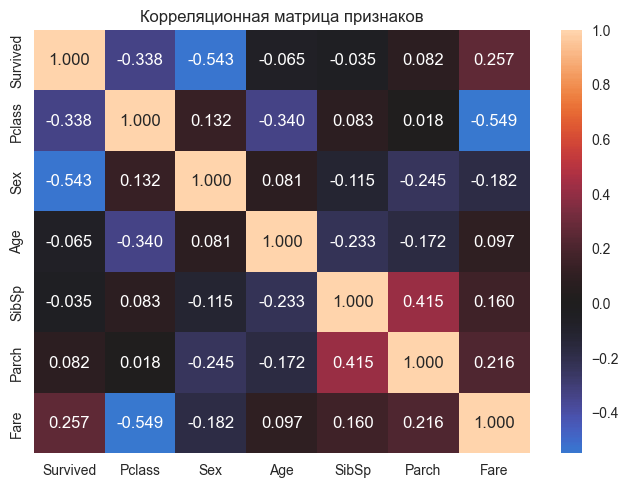

In [143]:
sns.heatmap(corr_matrix, annot=True, center=0, fmt='.3f')
plt.title('Корреляционная матрица признаков')
plt.show()

In [144]:
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

In [145]:
if high_corr:
    print("Обнаружена высокая корреляция (>0.7):")
    for pair in high_corr:
        print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("Сильной корреляции между признаками не обнаружено (<0.7)")

Сильной корреляции между признаками не обнаружено (<0.7)


Сильной корреляции между признаками не обнаружено (все коэффициенты < 0.7), следовательно, мультиколлинеарность отсутствует. Это означает, что все признаки можно безопасно использовать в модели без риска дублирования информации или искажения коэффициентов.

### 17) Проведите группировку данных по значению возраста. Введите новый признак "возрастная категория", значениями которой будут "ребенок", "взрослый", "старик". Проведите анализ эффективности данного признака.

In [163]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [164]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [165]:
def age_category(age):
    if age < 18:
        return 'child'
    elif age < 60:
        return 'adult'
    else:
        return 'senior'

In [166]:
df['Age_Category'] = df['Age'].apply(age_category)

In [171]:
print(f"Дети: {df[df['Age_Category']=='child']['Survived'].mean():.1%}")
print(f"Взрослые: {df[df['Age_Category']=='adult']['Survived'].mean():.1%}")
print(f"Старики: {df[df['Age_Category']=='senior']['Survived'].mean():.1%}")

Дети: 54.0%
Взрослые: 36.4%
Старики: 26.9%


In [172]:
df['Sex'] = (df['Sex'] == 'male').astype(int)
df['IsChild'] = (df['Age_Category'] == 'child').astype(int)
df['IsSenior'] = (df['Age_Category'] == 'senior').astype(int)

In [173]:
X = df[['Pclass', 'Sex', 'Fare', 'IsChild', 'IsSenior']]
y = df['Survived']

In [174]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [175]:
print(f"Точность модели: {accuracy_score(y_test, y_pred):.3f}")

Точность модели: 0.788


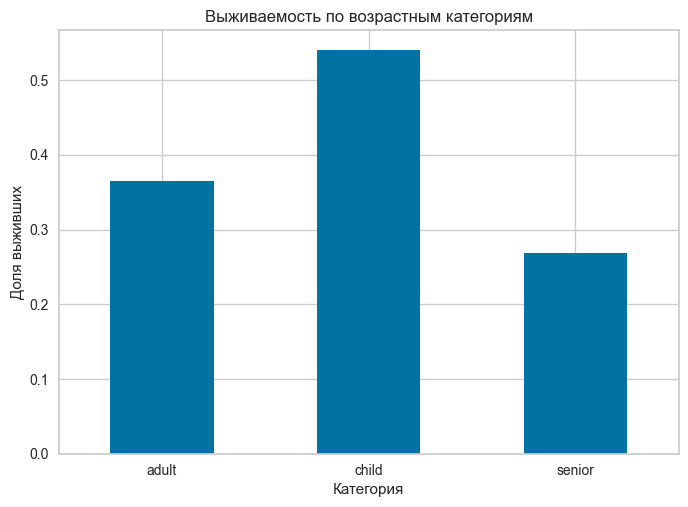

In [177]:
df.groupby('Age_Category')['Survived'].mean().plot(kind='bar')
plt.title('Выживаемость по возрастным категориям')
plt.xlabel('Категория')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)
plt.show()

Дети выживают чаще (>50%), старики реже (<30%)